# Chinook SQL Analysis

## Project Overview

This project analyzes the Chinook database using SQL and SQLite to answer business questions related to customer behavior, sales performance, and music trends.

The goal of this analysis is to demonstrate SQL querying skills, database exploration, and the ability to extract meaningful insights from relational data.

In [54]:
import sqlite3

connection = sqlite3.connect("Chinook_Sqlite.sqlite")

cursor = connection.cursor()

In [55]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

tables = cursor.fetchall()

tables

[('Album',),
 ('Artist',),
 ('Customer',),
 ('Employee',),
 ('Genre',),
 ('Invoice',),
 ('InvoiceLine',),
 ('MediaType',),
 ('Playlist',),
 ('PlaylistTrack',),
 ('Track',)]

## Database Structure

The Chinook database is a relational database containing information about customers, invoices, tracks, artists, albums, and sales transactions.

The tables will be analyzed using SQL queries to identify customer behavior, sales trends, and revenue patterns.

In [56]:
cursor.execute("""
PRAGMA table_info(Customer);
""")

customer_columns = cursor.fetchall()

customer_columns

[(0, 'CustomerId', 'INTEGER', 1, None, 1),
 (1, 'FirstName', 'NVARCHAR(40)', 1, None, 0),
 (2, 'LastName', 'NVARCHAR(20)', 1, None, 0),
 (3, 'Company', 'NVARCHAR(80)', 0, None, 0),
 (4, 'Address', 'NVARCHAR(70)', 0, None, 0),
 (5, 'City', 'NVARCHAR(40)', 0, None, 0),
 (6, 'State', 'NVARCHAR(40)', 0, None, 0),
 (7, 'Country', 'NVARCHAR(40)', 0, None, 0),
 (8, 'PostalCode', 'NVARCHAR(10)', 0, None, 0),
 (9, 'Phone', 'NVARCHAR(24)', 0, None, 0),
 (10, 'Fax', 'NVARCHAR(24)', 0, None, 0),
 (11, 'Email', 'NVARCHAR(60)', 1, None, 0),
 (12, 'SupportRepId', 'INTEGER', 0, None, 0)]

## SQL Analysis

The following SQL queries analyze customer behavior, sales performance, and product trends within the Chinook database.

Each query is designed to answer a business question and identify meaningful insights from the data.

In [57]:
cursor.execute("""
SELECT
    Country,
    COUNT(CustomerId) AS Number_of_Customers
FROM Customer
GROUP BY Country
ORDER BY Number_of_Customers DESC;
""")

customer_countries = cursor.fetchall()

customer_countries

[('USA', 13),
 ('Canada', 8),
 ('France', 5),
 ('Brazil', 5),
 ('Germany', 4),
 ('United Kingdom', 3),
 ('Portugal', 2),
 ('India', 2),
 ('Czech Republic', 2),
 ('Sweden', 1),
 ('Spain', 1),
 ('Poland', 1),
 ('Norway', 1),
 ('Netherlands', 1),
 ('Italy', 1),
 ('Ireland', 1),
 ('Hungary', 1),
 ('Finland', 1),
 ('Denmark', 1),
 ('Chile', 1),
 ('Belgium', 1),
 ('Austria', 1),
 ('Australia', 1),
 ('Argentina', 1)]

## Insight

The United States has the highest number of customers in the Chinook database with 13 customers, followed by Canada with 8 customers. This suggests that North America represents the largest customer market in this dataset. The company may benefit from focusing marketing efforts and customer engagement strategies in these regions.

## Customer Spending Analysis

This analysis identifies the highest-spending customers by combining customer information with invoice data.

In [58]:
cursor.execute("""
SELECT
    Customer.FirstName || ' ' || Customer.LastName AS Customer_Name,
    Customer.Country,
    SUM(Invoice.Total) AS Total_Spent
FROM Customer
JOIN Invoice
ON Customer.CustomerId = Invoice.CustomerId
GROUP BY Customer.CustomerId
ORDER BY Total_Spent DESC
LIMIT 10;
""")

top_customers = cursor.fetchall()

top_customers

[('Helena Holý', 'Czech Republic', 49.620000000000005),
 ('Richard Cunningham', 'USA', 47.620000000000005),
 ('Luis Rojas', 'Chile', 46.62),
 ('Ladislav Kovács', 'Hungary', 45.62),
 ("Hugh O'Reilly", 'Ireland', 45.62),
 ('Julia Barnett', 'USA', 43.620000000000005),
 ('Frank Ralston', 'USA', 43.62),
 ('Fynn Zimmermann', 'Germany', 43.62),
 ('Astrid Gruber', 'Austria', 42.62),
 ('Victor Stevens', 'USA', 42.62)]

## Insight

The highest-spending customer in the Chinook database is Helena Holý from the Czech Republic, with total purchases of $49.62. Customers from multiple countries appear among the top spenders, showing that valuable customers are distributed internationally. The company can use this information to identify high-value customers and develop targeted retention strategies.

## Sales Trend Analysis

This analysis examines monthly sales performance by grouping invoice data by month and calculating total revenue over time.

In [59]:
cursor.execute("""
SELECT
    strftime('%Y-%m', InvoiceDate) AS Sales_Month,
    ROUND(SUM(Total), 2) AS Monthly_Revenue
FROM Invoice
GROUP BY Sales_Month
ORDER BY Sales_Month;
""")

monthly_sales = cursor.fetchall()

monthly_sales

[('2021-01', 35.64),
 ('2021-02', 37.62),
 ('2021-03', 37.62),
 ('2021-04', 37.62),
 ('2021-05', 37.62),
 ('2021-06', 37.62),
 ('2021-07', 37.62),
 ('2021-08', 37.62),
 ('2021-09', 37.62),
 ('2021-10', 37.62),
 ('2021-11', 37.62),
 ('2021-12', 37.62),
 ('2022-01', 52.62),
 ('2022-02', 46.62),
 ('2022-03', 44.62),
 ('2022-04', 37.62),
 ('2022-05', 37.62),
 ('2022-06', 37.62),
 ('2022-07', 37.62),
 ('2022-08', 37.62),
 ('2022-09', 36.63),
 ('2022-10', 37.62),
 ('2022-11', 37.62),
 ('2022-12', 37.62),
 ('2023-01', 37.62),
 ('2023-02', 37.62),
 ('2023-03', 37.62),
 ('2023-04', 51.62),
 ('2023-05', 42.62),
 ('2023-06', 50.62),
 ('2023-07', 37.62),
 ('2023-08', 37.62),
 ('2023-09', 37.62),
 ('2023-10', 37.62),
 ('2023-11', 23.76),
 ('2023-12', 37.62),
 ('2024-01', 37.62),
 ('2024-02', 37.62),
 ('2024-03', 37.62),
 ('2024-04', 37.62),
 ('2024-05', 37.62),
 ('2024-06', 37.62),
 ('2024-07', 39.62),
 ('2024-08', 47.62),
 ('2024-09', 46.71),
 ('2024-10', 42.62),
 ('2024-11', 37.62),
 ('2024-12', 

## Insight

Monthly revenue in the Chinook database remained relatively consistent over time, with most months generating similar revenue totals. Some months showed higher sales activity, including January 2022, April 2023, June 2023, and November 2025. Because Chinook is a sample database, revenue patterns should be interpreted as a demonstration of SQL analysis rather than a complete representation of real-world sales performance.

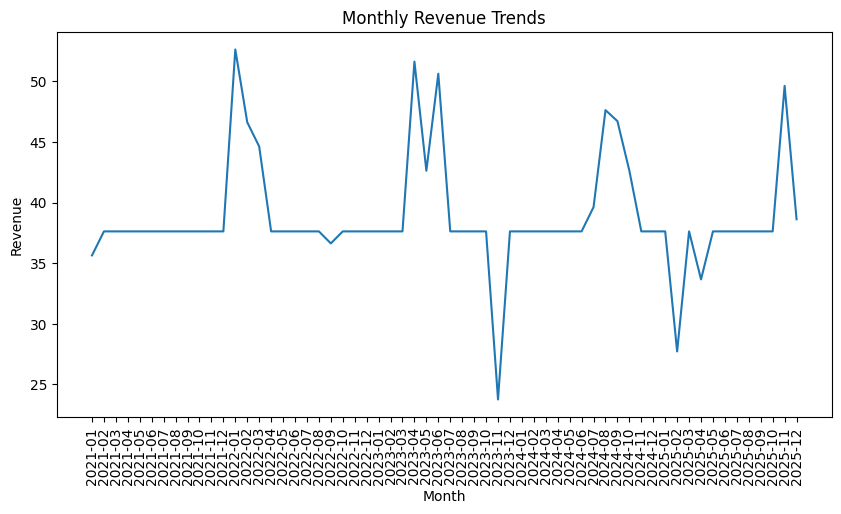

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

monthly_sales_df = pd.DataFrame(
    monthly_sales,
    columns=["Sales_Month", "Monthly_Revenue"]
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales_df["Sales_Month"],
    monthly_sales_df["Monthly_Revenue"]
)

plt.title("Monthly Revenue Trends")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

## Genre Revenue Analysis

This analysis identifies which music genres generate the highest revenue by combining genre information with track and invoice data.

In [61]:
cursor.execute("""
SELECT
    Genre.Name AS Genre,
    ROUND(SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity), 2) AS Revenue
FROM Genre
JOIN Track
ON Genre.GenreId = Track.GenreId
JOIN InvoiceLine
ON Track.TrackId = InvoiceLine.TrackId
GROUP BY Genre.GenreId
ORDER BY Revenue DESC;
""")

genre_revenue = cursor.fetchall()

genre_revenue

[('Rock', 826.65),
 ('Latin', 382.14),
 ('Metal', 261.36),
 ('Alternative & Punk', 241.56),
 ('TV Shows', 93.53),
 ('Jazz', 79.2),
 ('Blues', 60.39),
 ('Drama', 57.71),
 ('Classical', 40.59),
 ('R&B/Soul', 40.59),
 ('Sci Fi & Fantasy', 39.8),
 ('Reggae', 29.7),
 ('Pop', 27.72),
 ('Soundtrack', 19.8),
 ('Comedy', 17.91),
 ('Hip Hop/Rap', 16.83),
 ('Bossa Nova', 14.85),
 ('Alternative', 13.86),
 ('World', 12.87),
 ('Science Fiction', 11.94),
 ('Electronica/Dance', 11.88),
 ('Heavy Metal', 11.88),
 ('Easy Listening', 9.9),
 ('Rock And Roll', 5.94)]

## Insight

Rock is the highest revenue-generating genre in the Chinook database, producing $826.65 in sales. Latin and Metal are the next strongest-performing genres. These results suggest that Rock content represents a significant portion of customer purchases, while lower-performing genres may require different marketing strategies or targeted promotions to increase engagement.

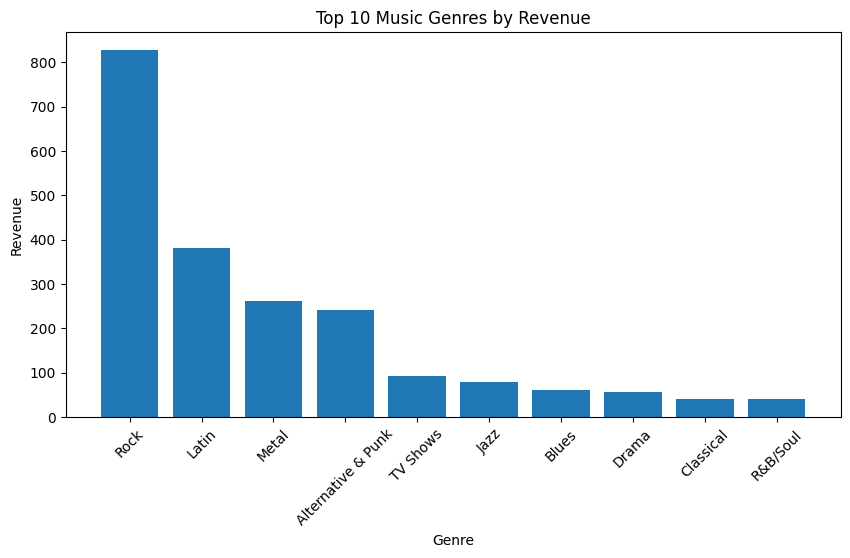

In [62]:
genre_revenue_df = pd.DataFrame(
    genre_revenue,
    columns=["Genre", "Revenue"]
)

top_genres = genre_revenue_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_genres["Genre"],
    top_genres["Revenue"]
)

plt.title("Top 10 Music Genres by Revenue")
plt.xlabel("Genre")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Artist Revenue Analysis

This analysis identifies the highest revenue-generating artists by connecting artist, album, track, and sales transaction data.

In [63]:
cursor.execute("""
SELECT
    Artist.Name AS Artist,
    ROUND(SUM(InvoiceLine.UnitPrice * InvoiceLine.Quantity), 2) AS Revenue
FROM Artist
JOIN Album
ON Artist.ArtistId = Album.ArtistId
JOIN Track
ON Album.AlbumId = Track.AlbumId
JOIN InvoiceLine
ON Track.TrackId = InvoiceLine.TrackId
GROUP BY Artist.ArtistId
ORDER BY Revenue DESC
LIMIT 10;
""")

artist_revenue = cursor.fetchall()

artist_revenue

[('Iron Maiden', 138.6),
 ('U2', 105.93),
 ('Metallica', 90.09),
 ('Led Zeppelin', 86.13),
 ('Lost', 81.59),
 ('The Office', 49.75),
 ('Os Paralamas Do Sucesso', 44.55),
 ('Deep Purple', 43.56),
 ('Faith No More', 41.58),
 ('Eric Clapton', 39.6)]

## Insight

Iron Maiden generated the highest revenue in the Chinook database with $138.60 in sales, followed by U2 and Metallica. The results show that a small group of artists contributes a significant portion of total revenue. These findings could help guide promotional strategies by highlighting high-performing artists.

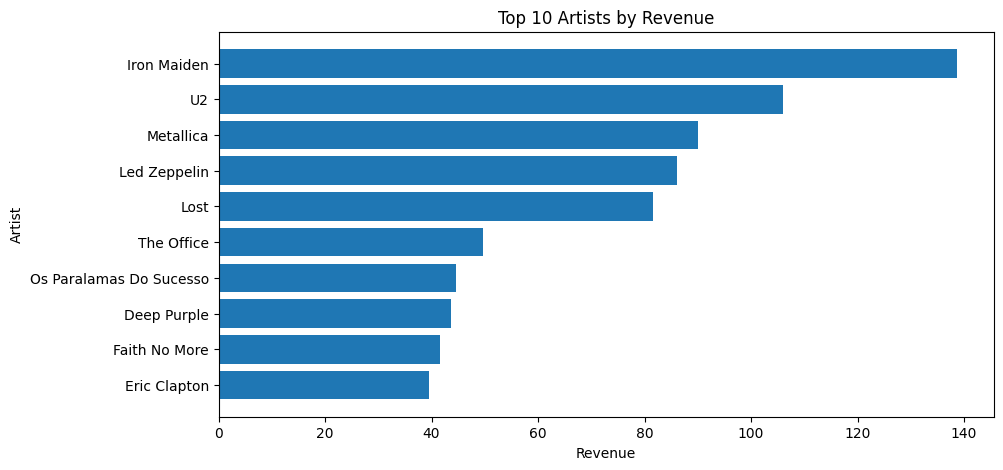

In [64]:
artist_revenue_df = pd.DataFrame(
    artist_revenue,
    columns=["Artist", "Revenue"]
)

plt.figure(figsize=(10,5))

plt.barh(
    artist_revenue_df["Artist"],
    artist_revenue_df["Revenue"]
)

plt.title("Top 10 Artists by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Artist")

plt.gca().invert_yaxis()

plt.show()

## Employee Customer Support Analysis

This analysis examines how many customers are assigned to each support representative in the Chinook database.

In [65]:
cursor.execute("""
SELECT
    Employee.FirstName || ' ' || Employee.LastName AS Employee_Name,
    COUNT(Customer.CustomerId) AS Customers_Assigned
FROM Employee
JOIN Customer
ON Employee.EmployeeId = Customer.SupportRepId
GROUP BY Employee.EmployeeId
ORDER BY Customers_Assigned DESC;
""")

employee_customers = cursor.fetchall()

employee_customers

[('Jane Peacock', 21), ('Margaret Park', 20), ('Steve Johnson', 18)]

## Insight

Jane Peacock manages the largest number of customers in the Chinook database with 21 assigned customers, followed closely by Margaret Park with 20 customers and Steve Johnson with 18 customers. The customer assignments are relatively balanced across support representatives, suggesting an even distribution of workload among the support team.

# Final Conclusions

## Summary of Findings

This project analyzed the Chinook database using SQL and SQLite to explore customer behavior, sales performance, music trends, and employee workload.

Key findings from the analysis include:

- The United States had the largest customer base, followed by Canada, showing that North America represents an important market within the dataset.

- The highest-spending customers were distributed across multiple countries, showing that valuable customers are not limited to one geographic region.

- Monthly revenue remained relatively consistent over time, with occasional increases during specific months.

- Rock was the highest revenue-generating music genre, significantly outperforming other genres in total sales.

- Iron Maiden generated the highest revenue among artists, followed by U2 and Metallica.

- Customer support assignments were evenly distributed among employees, with Jane Peacock managing the largest number of customers.

## Skills Demonstrated

This project demonstrates skills in:

- SQL querying
- SQLite database management
- Relational database concepts
- Data exploration
- Data aggregation
- SQL JOIN operations
- Revenue analysis
- Data visualization
- Business insight generation

## Conclusion

The Chinook database provided an opportunity to practice extracting meaningful business insights from relational data. By combining SQL analysis with visualization and written interpretation, this project demonstrates the ability to transform raw database information into actionable findings.